# 08_phase3_composition_scCODA.ipynb
Phase 3 — Compositional Analysis (scCODA)

**Why scCODA instead of the Phase 2 Kruskal-Wallis pass:** cell-type proportions are compositional data — they sum to 100% within each sample, so cell types aren't statistically independent (if one goes up, something else must go down). Standard tests (Kruskal-Wallis, Mann-Whitney) don't account for this. scCODA uses a Bayesian Dirichlet-Multinomial model built specifically for compositional data, modelling every cell type's change relative to one chosen reference type.

**Reference cell type choice matters** — it should be a population unlikely to be the one driving the biological difference under test, since scCODA's results are always interpreted relative to it. Chosen deliberately per comparison below, not defaulted.

In [3]:
# ----------------------------
# Cell 1 — Imports and paths
# ----------------------------
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from sccoda.util import cell_composition_data as scc_dat
    from sccoda.util import comp_ana as scc_ana
    print("sccoda imported successfully")
except ImportError:
    print("sccoda not installed. Run: pip install sccoda")
    raise

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
RESULTS_DIR = PROJECT_DIR / "results" / "phase3_composition_sccoda"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase3_composition_sccoda"

for d in [RESULTS_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXCLUDE_TYPES = ["Unassigned (n=28, doublet/mixed-identity artefact)",
                  "Mixed/stromal-contaminated (CD8+fibroblast signal)"]

print("Setup complete")

C:\Users\annam\anaconda3\envs\scrna\lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


sccoda imported successfully
Setup complete


In [2]:
# ----------------------------
# Cell 2 — Build sample x cell_type count table (scCODA input format)
# scCODA expects an AnnData where obs = samples (not cells!) and
# var = cell types, X = counts of each cell type per sample.
# ----------------------------
def build_composition_anndata(adata_obs, sample_col, condition_col, exclude_types=EXCLUDE_TYPES):
    df = adata_obs[~adata_obs["cell_type"].isin(exclude_types)].copy()
    counts = df.groupby([sample_col, "cell_type"], observed=True).size().unstack(fill_value=0)

    condition_lookup = df.drop_duplicates(sample_col).set_index(sample_col)[condition_col]
    sample_meta = pd.DataFrame({condition_col: condition_lookup})

    comp_adata = scc_dat.from_pandas(counts, covariate_columns=[])
    comp_adata.obs[condition_col] = sample_meta.loc[comp_adata.obs_names, condition_col].values

    return comp_adata

print("Composition AnnData builder ready")

Composition AnnData builder ready


In [3]:
# ----------------------------
# Cell 3 — GSE114725: Tumour vs Normal
# Reference: T cells — the largest, most stable population, and not
# expected a priori to be THE cell type driving tumour/normal difference
# (macrophages are the stronger candidate for that, per DE/LIANA
# findings already established — using them as reference could bias
# results toward finding everything else "changed" relative to them).
# ----------------------------
adata1 = sc.read_h5ad(PROCESSED_DIR / "GSE114725_phase2_v2_annotated.h5ad", backed="r")
obs1 = adata1.obs[adata1.obs["tissue"].isin(["TUMOR", "NORMAL"])].copy()

comp_adata1 = build_composition_anndata(obs1, sample_col="patient", condition_col="tissue")
print(f"GSE114725 composition data: {comp_adata1.n_obs} samples x {comp_adata1.n_vars} cell types")
print(comp_adata1.obs)

model1 = scc_ana.CompositionalAnalysis(
    comp_adata1, formula="tissue", reference_cell_type="T cells"
)
result1 = model1.sample_hmc()
print("\n" + "="*60)
print("GSE114725: Tumour vs Normal — scCODA results")
print("="*60)
result1.summary()

GSE114725 composition data: 8 samples x 8 cell types
cell_type  tissue
patient          
BC1        NORMAL
BC2        NORMAL
BC3        NORMAL
BC4         TUMOR
BC5         TUMOR
BC6         TUMOR
BC7        NORMAL
BC8         TUMOR


100%|██████████| 20000/20000 [01:35<00:00, 209.77it/s]


MCMC sampling finished. (124.114 sec)
Acceptance rate: 48.2%

GSE114725: Tumour vs Normal — scCODA results
Compositional Analysis summary:

Data: 8 samples, 8 cell types
Reference index: 0
Formula: tissue

Intercepts:
                      Final Parameter  Expected Sample
Cell Type                                             
T cells                         1.260       689.284728
CD8/Effector T cells            1.358       760.255404
NK/Cytotoxic T cells            0.394       289.934326
B cells                        -0.133       171.169524
Macrophages                     1.228       667.576796
pDC                            -1.035        69.453290
Monocytes/DC                   -0.894        79.970230
Mast cells                     -0.696        97.480702


Effects:
                                          Final Parameter  Expected Sample  \
Covariate           Cell Type                                                
tissue[T.LYMPHNODE] T cells                           0.0       6

In [4]:
# Cell 4 — GSE114725: extract and save credible effects
effects1 = result1.effect_df
effects1.to_csv(RESULTS_DIR / "GSE114725_scCODA_tumor_vs_normal_effects.csv")
print(effects1)

credible1 = result1.credible_effects()
print("\nCredible (confidently non-zero) effects:")
print(credible1)

                                          Final Parameter  HDI 3%  HDI 97%  \
Covariate           Cell Type                                                
tissue[T.LYMPHNODE] T cells                           0.0   0.000    0.000   
                    CD8/Effector T cells              0.0  -6.442   11.827   
                    NK/Cytotoxic T cells              0.0 -11.461   10.265   
                    B cells                           0.0  -9.999   11.239   
                    Macrophages                       0.0  -9.472    8.223   
                    pDC                               0.0 -15.244    5.574   
                    Monocytes/DC                      0.0  -9.162    6.671   
                    Mast cells                        0.0  -7.905   12.371   
tissue[T.NORMAL]    T cells                           0.0   0.000    0.000   
                    CD8/Effector T cells              0.0  -0.693    0.385   
                    NK/Cytotoxic T cells              0.0  -0.78

In [5]:
# Cell 5 — GSE176078: pairwise subtype comparisons
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad", backed="r")

pairwise_comparisons = [("TNBC", "ER+"), ("HER2+", "ER+"), ("TNBC", "HER2+")]
all_sccoda_results_2 = {}

for group_a, group_b in pairwise_comparisons:
    comparison_name = f"{group_a}_vs_{group_b}"
    obs2_sub = adata2.obs[adata2.obs["subtype"].isin([group_a, group_b])].copy()
    obs2_sub["subtype"] = obs2_sub["subtype"].astype(str)  # drop unused categorical levels

    comp_adata2 = build_composition_anndata(obs2_sub, sample_col="orig.ident", condition_col="subtype")
    print(f"\n{comparison_name}: {comp_adata2.n_obs} samples x {comp_adata2.n_vars} cell types")

    model2 = scc_ana.CompositionalAnalysis(
        comp_adata2, formula="subtype", reference_cell_type="PVL"
    )
    result2 = model2.sample_hmc()

    print(f"=== GSE176078: {comparison_name} — scCODA results ===")
    result2.summary()

    effects2 = result2.effect_df
    effects2.to_csv(RESULTS_DIR / f"GSE176078_scCODA_{comparison_name}_effects.csv")
    all_sccoda_results_2[comparison_name] = result2

    credible2 = result2.credible_effects()
    print(f"\nCredible effects ({comparison_name}):")
    print(credible2)
    gc.collect()

print("\nGSE176078 scCODA complete")


TNBC_vs_ER+: 21 samples x 16 cell types
Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [02:29<00:00, 134.03it/s]


MCMC sampling finished. (190.111 sec)
Acceptance rate: 47.9%
=== GSE176078: TNBC_vs_ER+ — scCODA results ===
Compositional Analysis summary:

Data: 21 samples, 16 cell types
Reference index: 12
Formula: subtype

Intercepts:
                        Final Parameter  Expected Sample
Cell Type                                               
B cells                          -1.050       122.047222
Basal epithelial                 -1.471        80.110588
CAFs                             -0.258       269.456787
CD8 T cells                      -0.118       309.949082
Cycling T cells                  -1.232       101.738727
Cycling epithelial               -0.826       152.689742
Endothelial cells                -0.048       332.422926
Epithelial (ambiguous)           -0.862       147.290677
Luminal epithelial                0.347       493.443336
Macrophages                       0.042       363.728617
Memory T cells                   -0.286       262.016645
NK cells                         -0

100%|██████████| 20000/20000 [02:20<00:00, 142.68it/s]


MCMC sampling finished. (179.980 sec)
Acceptance rate: 49.9%
=== GSE176078: HER2+_vs_ER+ — scCODA results ===
Compositional Analysis summary:

Data: 16 samples, 16 cell types
Reference index: 12
Formula: subtype

Intercepts:
                        Final Parameter  Expected Sample
Cell Type                                               
B cells                          -0.883       124.307072
Basal epithelial                 -1.491        67.677575
CAFs                             -0.256       232.701122
CD8 T cells                      -0.009       297.899116
Cycling T cells                  -1.296        82.249301
Cycling epithelial               -0.919       119.911610
Endothelial cells                 0.185       361.678209
Epithelial (ambiguous)           -1.008       109.700606
Luminal epithelial                0.497       494.108383
Macrophages                      -0.034       290.543960
Memory T cells                   -0.104       270.901393
NK cells                         -

100%|██████████| 20000/20000 [02:24<00:00, 138.26it/s]


MCMC sampling finished. (180.321 sec)
Acceptance rate: 44.6%
=== GSE176078: TNBC_vs_HER2+ — scCODA results ===
Compositional Analysis summary:

Data: 15 samples, 16 cell types
Reference index: 12
Formula: subtype

Intercepts:
                        Final Parameter  Expected Sample
Cell Type                                               
B cells                          -0.617       130.363892
Basal epithelial                 -1.304        65.583865
CAFs                              0.058       256.038982
CD8 T cells                       0.939       617.901901
Cycling T cells                  -0.898        98.428432
Cycling epithelial               -0.659       125.001996
Endothelial cells                -0.212       195.454909
Epithelial (ambiguous)           -0.503       146.105609
Luminal epithelial               -0.003       240.887425
Macrophages                       0.456       381.202110
Memory T cells                    1.004       659.399589
NK cells                         

Verification — mean per subtype (should match: ER+ 7.7%, HER2+ 19.2%, TNBC 7.8%):
subtype
ER+       7.660823
HER2+    19.155738
TNBC      7.808738
Name: memory_t_pct, dtype: float64


C:\Users\annam\AppData\Local\Temp\ipykernel_9816\3746855978.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(result.groupby("subtype")["memory_t_pct"].mean())
C:\Users\annam\AppData\Local\Temp\ipykernel_9816\3746855978.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=order, patch_artist=True, showmeans=True)


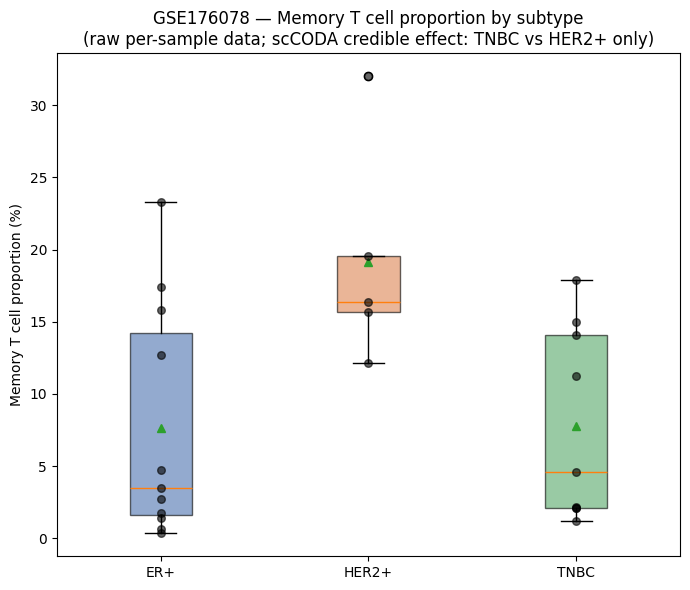


Saved (overwriting previous, incorrect version)


In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase3_composition_sccoda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# CORRECTED data pipeline — matches the verified, fixed groupby logic
# ----------------------------
adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad", backed="r")
obs2 = adata2.obs[["orig.ident", "subtype", "cell_type"]].copy()
del adata2

patient_subtype = obs2.drop_duplicates(subset="orig.ident")[["orig.ident", "subtype"]].set_index("orig.ident")

total_per_patient = obs2.groupby("orig.ident", observed=True).size()
memory_per_patient = obs2[obs2["cell_type"] == "Memory T cells"].groupby("orig.ident", observed=True).size()
memory_pct = (memory_per_patient / total_per_patient * 100).reindex(total_per_patient.index, fill_value=0)

result = patient_subtype.copy()
result["memory_t_pct"] = memory_pct

print("Verification — mean per subtype (should match: ER+ 7.7%, HER2+ 19.2%, TNBC 7.8%):")
print(result.groupby("subtype")["memory_t_pct"].mean())

# ----------------------------
# Boxplot — built from CORRECTED data
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 6))
order = ["ER+", "HER2+", "TNBC"]
data_by_group = [result[result["subtype"] == g]["memory_t_pct"].dropna().values for g in order]

bp = ax.boxplot(data_by_group, labels=order, patch_artist=True, showmeans=True)
colors = ["#4c72b0", "#dd8452", "#55a868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for i, g in enumerate(order, start=1):
    y = result[result["subtype"] == g]["memory_t_pct"].dropna().values
    ax.scatter([i] * len(y), y, color="black", alpha=0.6, s=30, zorder=3)

ax.set_ylabel("Memory T cell proportion (%)")
ax.set_title("GSE176078 — Memory T cell proportion by subtype\n(raw per-sample data; scCODA credible effect: TNBC vs HER2+ only)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_MemoryT_boxplot_by_subtype.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("\nSaved (overwriting previous, incorrect version)")

In [2]:
import scanpy as sc
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"

adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad", backed="r")
obs2 = adata2.obs[["orig.ident", "subtype", "cell_type"]].copy()
del adata2

obs2_sub = obs2[obs2["subtype"].isin(["TNBC", "HER2+"])].copy()
comp = obs2_sub.groupby(["orig.ident", "subtype"], observed=True)["cell_type"] \
    .value_counts(normalize=True).unstack(fill_value=0) * 100
comp = comp.reset_index()

print(f"Total rows: {len(comp)} (should be 15 — 10 TNBC + 5 HER2+, one row per patient)")
print(comp["subtype"].value_counts())
print(f"\nUnique patients: {comp['orig.ident'].nunique()}")

# Check for the specific known patient again
print(f"\nCID45171 rows:")
print(comp[comp["orig.ident"] == "CID45171"][["orig.ident", "subtype"]])

print(f"\nMemory T cells mean by subtype (should be TNBC~7.8%, HER2+~19.2%):")
print(comp.groupby("subtype")["Memory T cells"].mean())

Total rows: 30 (should be 15 — 10 TNBC + 5 HER2+, one row per patient)
subtype
HER2+    15
TNBC     15
ER+       0
Name: count, dtype: int64

Unique patients: 15

CID45171 rows:
cell_type orig.ident subtype
28          CID45171   HER2+
29          CID45171    TNBC

Memory T cells mean by subtype (should be TNBC~7.8%, HER2+~19.2%):
subtype
ER+           NaN
HER2+    6.385246
TNBC     4.685243
Name: Memory T cells, dtype: float64


C:\Users\annam\AppData\Local\Temp\ipykernel_9816\2263827647.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(comp.groupby("subtype")["Memory T cells"].mean())


Total rows: 15 (should be 15)
subtype
TNBC     10
HER2+     5
Name: count, dtype: int64

CID45171: HER2+

Memory T cells mean by subtype:
subtype
HER2+    19.155738
TNBC      7.808738
Name: Memory T cells, dtype: float64


C:\Users\annam\AppData\Local\Temp\ipykernel_9816\870410126.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=["TNBC", "HER2+"], patch_artist=True, widths=0.5)
C:\Users\annam\AppData\Local\Temp\ipykernel_9816\870410126.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=["TNBC", "HER2+"], patch_artist=True, widths=0.5)
C:\Users\annam\AppData\Local\Temp\ipykernel_9816\870410126.py:60: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=["TNBC", "HER2+"], patch_artist=True, widths=0.5)
C:\Users\annam\AppData\Lo

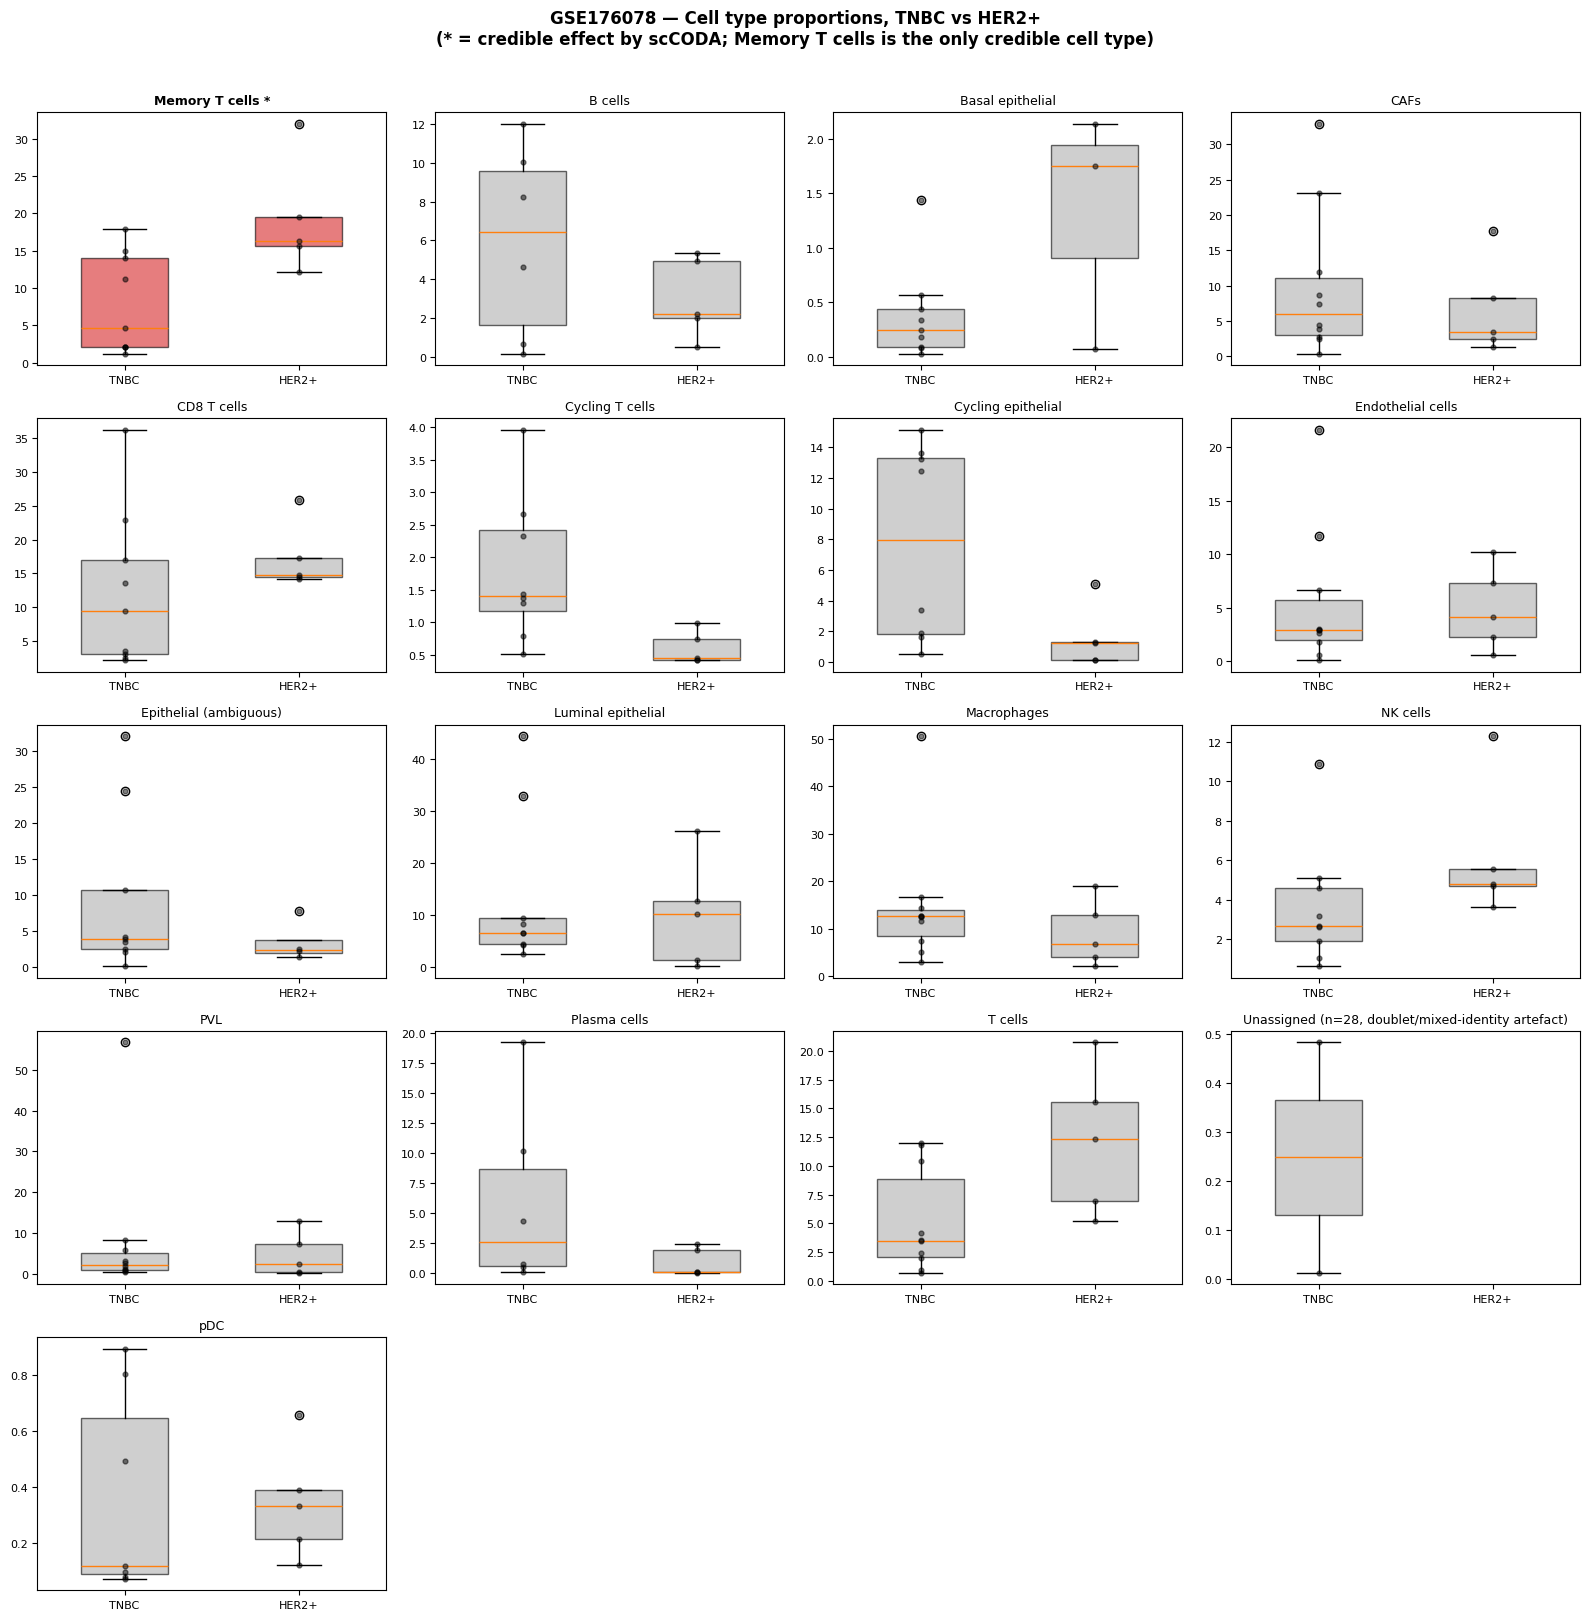


Saved (overwriting previous, incorrect version)


In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\annam\Dissertation 2026")
PROCESSED_DIR = PROJECT_DIR / "Data" / "Processed"
RESULTS_DIR = PROJECT_DIR / "results" / "phase3_composition_sccoda"
FIGURE_DIR = PROJECT_DIR / "figures" / "phase3_composition_sccoda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

adata2 = sc.read_h5ad(PROCESSED_DIR / "GSE176078_phase2_v2_annotated_corrected.h5ad", backed="r")
obs2 = adata2.obs[["orig.ident", "subtype", "cell_type"]].copy()
del adata2

# ----------------------------
# CORRECTED approach: cast subtype to str FIRST, avoiding the
# categorical dtype's retained-unused-categories bug entirely
# ----------------------------
obs2["subtype"] = obs2["subtype"].astype(str)
obs2_sub = obs2[obs2["subtype"].isin(["TNBC", "HER2+"])].copy()

patient_subtype = obs2_sub.drop_duplicates(subset="orig.ident")[["orig.ident", "subtype"]].set_index("orig.ident")
total_per_patient = obs2_sub.groupby("orig.ident", observed=True).size()

cell_types = obs2_sub["cell_type"].unique().tolist()
comp = pd.DataFrame(index=total_per_patient.index)
for ct in cell_types:
    ct_counts = obs2_sub[obs2_sub["cell_type"] == ct].groupby("orig.ident", observed=True).size()
    comp[ct] = (ct_counts / total_per_patient * 100).reindex(total_per_patient.index, fill_value=0)
comp["subtype"] = patient_subtype["subtype"]

print(f"Total rows: {len(comp)} (should be 15)")
print(comp["subtype"].value_counts())
print(f"\nCID45171: {comp.loc['CID45171', 'subtype'] if 'CID45171' in comp.index else 'not found'}")
print(f"\nMemory T cells mean by subtype:")
print(comp.groupby("subtype")["Memory T cells"].mean())

# ----------------------------
# Load credibility from the confirmed-correct effects file
# ----------------------------
credible_df = pd.read_csv(RESULTS_DIR / "GSE176078_scCODA_TNBC_vs_HER2+_effects.csv")
credible_lookup = credible_df.set_index("Cell Type")["Final Parameter"] != 0

cell_types_sorted = sorted(cell_types, key=lambda c: (not credible_lookup.get(c, False), c))

# ----------------------------
# Grid of boxplots
# ----------------------------
n_cols = 4
n_rows = int(np.ceil(len(cell_types_sorted) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.2))
axes = axes.flatten()

for i, ct in enumerate(cell_types_sorted):
    ax = axes[i]
    is_credible = credible_lookup.get(ct, False)
    data_by_group = [comp[comp["subtype"] == g][ct].dropna().values for g in ["TNBC", "HER2+"]]
    bp = ax.boxplot(data_by_group, labels=["TNBC", "HER2+"], patch_artist=True, widths=0.5)
    color = "#d62728" if is_credible else "#b0b0b0"
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for j, g in enumerate(["TNBC", "HER2+"], start=1):
        y = comp[comp["subtype"] == g][ct].dropna().values
        ax.scatter([j] * len(y), y, color="black", alpha=0.5, s=12, zorder=3)
    title = f"{ct}" + (" *" if is_credible else "")
    ax.set_title(title, fontsize=9, fontweight="bold" if is_credible else "normal")
    ax.tick_params(axis="both", labelsize=8)

for j in range(len(cell_types_sorted), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    "GSE176078 — Cell type proportions, TNBC vs HER2+\n"
    "(* = credible effect by scCODA; Memory T cells is the only credible cell type)",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "GSE176078_TNBC_vs_HER2_all_celltypes_boxplot.png",
            dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("\nSaved (overwriting previous, incorrect version)")